# Notebook ?: Evaluation
Evaluates BM25 and Cosine Similarity retrieval on the 1906 Chronicling America corpus using manually labeled relevance judgments.

Qrels are stored in `../data/qrels.json`, edit that file to update labels, not this notebook.

## 1. Setup

In [49]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import pyterrier as pt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

os.environ["JAVA_HOME"] = "/Library/Java/JavaVirtualMachines/temurin-25.jdk/Contents/Home"
os.environ["JVM_PATH"]  = "/Library/Java/JavaVirtualMachines/temurin-25.jdk/Contents/Home/lib/server/libjvm.dylib"

if not pt.started():
    pt.init()

print("PyTerrier", pt.__version__)

PyTerrier 1.0.2


/var/folders/sj/z4b7r7m16t93q2qp3qwcwdwr0000gn/T/ipykernel_22285/1363158234.py:15: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


## 2. Load corpus & index

In [50]:
df = pd.read_parquet("../data/corpus.parquet")
print(f"Corpus: {len(df)} docs")
df.head(2)

Corpus: 608 docs


,doc_id,lccn,date,edition,page,raw_text,clean_text,token_count
0,sn83035387_1906_01_06_ed1_seq1,sn83035387,1906-01-06,1,1,TIIE G AZETTE\nTWENTY-THIRD YEAR. NO. 23.\nThe...,tiie azett twenti third year fashion uay autho...,3239
1,sn83035387_1906_01_06_ed1_seq2,sn83035387,1906-01-06,1,2,2\nTHE GAZETTE.\nPUBLISHED EVERY SATURDAY.\nSU...,gazett publish everi saturday subscript rate a...,3700


In [51]:
INDEX_PATH = "../data/pt_index"
index = pt.IndexFactory.of(INDEX_PATH)
print(index.getCollectionStatistics().toString())

Number of documents: 608
Number of terms: 54172
Number of postings: 688989
Number of fields: 0
Number of tokens: 1234007
Field names: []
Positions:   false



## 3. Queries

In [52]:
queries = pd.DataFrame([
    {"qid": "1",  "query": "earthquake fire san francisco"},
    {"qid": "2",  "query": "railroad strike labor"},
    {"qid": "3",  "query": "election president congress"},
    {"qid": "4",  "query": "war military troops"},
    {"qid": "5",  "query": "weather storm flood"},
    {"qid": "6",  "query": "crime murder trial"},
    {"qid": "7",  "query": "business market prices"},
    {"qid": "8",  "query": "church sunday religion"},
    {"qid": "9",  "query": "school education children"},
    {"qid": "10", "query": "disease death hospital"},
])
queries

,qid,query
0,1,earthquake fire san francisco
1,2,railroad strike labor
2,3,election president congress
3,4,war military troops
4,5,weather storm flood
5,6,crime murder trial
6,7,business market prices
7,8,church sunday religion
8,9,school education children
9,10,disease death hospital


## 4. Retrieve with BM25

In [53]:
bm25 = pt.terrier.Retriever(index, wmodel="BM25", num_results=20)
results = bm25.transform(queries)
print(f"Retrieved {len(results)} rows across {results['qid'].nunique()} queries")
results.head()

Retrieved 200 rows across 10 queries


,qid,docid,docno,rank,score,query
0,1,63,sn83035387_1906_04_21_ed1_seq4,0,14.774044,earthquake fire san francisco
1,1,347,sn84020235_1906_05_05_ed1_seq2,1,14.522445,earthquake fire san francisco
2,1,65,sn83035387_1906_04_28_ed1_seq2,2,14.116376,earthquake fire san francisco
3,1,351,sn84020235_1906_05_05_ed1_seq6,3,13.527361,earthquake fire san francisco
4,1,373,sn84020235_1906_05_26_ed1_seq4,4,13.508947,earthquake fire san francisco


## 5. Retrieve with Cosine Similarity
Loads the TF-IDF matrix and vectorizer saved by `Cosine_similarity.ipynb`.

In [54]:
tfidf_matrix = sp.load_npz("../data/tfidf_matrix.npz")
with open("../data/vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

def search_cosine(query, vectorizer, tfidf_matrix, corpus, top_k=10):
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, tfidf_matrix).flatten()
    ranked_indices = np.argsort(scores)[::-1]
    top_indices = ranked_indices[:top_k]
    res = corpus.iloc[top_indices].copy()
    res["score"] = scores[top_indices]
    return res[["doc_id", "score"]]

def run_cosine_search(query, top_k=10):
    return search_cosine(query, vectorizer, tfidf_matrix, df, top_k=top_k)

cosine_rows = []
for _, row in queries.iterrows():
    res = run_cosine_search(row["query"], top_k=20)
    for rank, (_, doc) in enumerate(res.iterrows()):
        cosine_rows.append({
            "qid":   row["qid"],
            "docno": doc["doc_id"],
            "rank":  rank,
            "score": doc["score"],
        })

cosine_results = pd.DataFrame(cosine_rows)
print(cosine_results.shape)
cosine_results.head(10)

(200, 4)


,qid,docno,rank,score
0,1,sn84020235_1906_04_21_ed1_seq2,0,0.371719
1,1,sn83035387_1906_04_21_ed1_seq4,1,0.227437
2,1,sn83035387_1906_04_28_ed1_seq2,2,0.223983
3,1,sn83035387_1906_05_12_ed1_seq2,3,0.172034
4,1,sn84020235_1906_05_05_ed1_seq6,4,0.155070
5,1,sn84020235_1906_05_12_ed1_seq6,5,0.148837
6,1,sn84020235_1906_05_26_ed1_seq4,6,0.119716
7,1,sn84020235_1906_04_28_ed1_seq2,7,0.112901
8,1,sn84020235_1906_05_05_ed1_seq2,8,0.107993
9,1,sn84020235_1906_04_28_ed1_seq6,9,0.099431


## 6. Inspect results
Use `show_results(qid)` to browse retrieved docs for any query — useful for labeling or sanity checking.

In [55]:
QUERY_LABELS = {
    "1":  "earthquake fire san francisco",
    "2":  "railroad strike labor",
    "3":  "election president congress",
    "4":  "war military troops",
    "5":  "weather storm flood",
    "6":  "crime murder trial",
    "7":  "business market prices",
    "8":  "church sunday religion",
    "9":  "school education children",
    "10": "disease death hospital",
}

def show_results(qid, result_df=None, top_n=20, text_len=600):
    """Print ranked results for a query with snippet text.
    
    Args:
        qid:       query id string, e.g. '1'
        result_df: results DataFrame (defaults to BM25 results)
        top_n:     how many results to show
        text_len:  characters of raw text to display per doc
    """
    if result_df is None:
        result_df = results
    subset = result_df[result_df["qid"] == str(qid)].head(top_n).reset_index(drop=True)
    print(f"Query {qid}: '{QUERY_LABELS.get(str(qid), '?')}' — {len(subset)} results")
    print("=" * 80)
    for _, row in subset.iterrows():
        doc_rows = df[df["doc_id"] == row["docno"]]
        if doc_rows.empty:
            print(f"rank {int(row['rank'])+1:>2} | {row['docno']} | [NOT FOUND IN CORPUS]")
            continue
        doc = doc_rows.iloc[0]
        date = str(doc.get("date", ""))[:10]
        score = f"{row['score']:.4f}" if "score" in row else ""
        print(f"rank {int(row['rank'])+1:>2} | score {score} | {row['docno']} | {date}")
        snippet = str(doc.get("raw_text", ""))[:text_len].replace("\n", " ")
        print(snippet)
        print("-" * 80)

# change qid to inspect any query; pass result_df=cosine_results to inspect cosine
show_results("6")

Query 6: 'crime murder trial' — 20 results
rank  1 | score 7.2923 | sn83035387_1906_10_13_ed1_seq1 | 1906-10-13
THE W GAZETTE TWENTY-FOURT BUCKEYE HAPPENINGS FROM MANY BUCKEYE CITIES AND TOWNS—SENT BY OUR OWN CORRESPONDENTS. • PERSONAL. SOCIAL, LODGE, CHURCH, LITERARY AND OTHER NOTES OF IN TEREST. Behefontaine.—Mrs. Scott, of South- Rend, Ind., is visiting her sister, Mrs. Bray. Mrs. Scott* Mrs. Bray and daughter visited in Mechanicsburg.— Rev. Dorsey was in Pickreltown Sun day.—Mrs. Laura Glaspy gave a re ception Thursday in honor of Mrs. Bertha Kinslin and Miss Roberta Stewart. —Mrs. Laura Clark has re turned from Cincinnati and Spring field.—-Grace church concert. Tuesday night was fine.—The Second B
--------------------------------------------------------------------------------
rank  2 | score 7.1446 | sn83035387_1906_12_15_ed1_seq1 | 1906-12-15
THE GAZETTE ■ay* ~^~E- TWENTY-FOURTH YEAR. NO. 20. THEY HURT. Some of the President’s Statements in His RECENT MESSAGE They Are Wrong—See

## 7. Load relevance judgments

Labels live in `../data/qrels.json`. Format:
```json
{
  "1": {
    "sn84020235_1906_05_05_ed1_seq6": 1,
    "sn83035387_1906_04_21_ed1_seq4": 0,
    ...
  },
  ...
}
```
Only docs with label=1 are included in qrels (non-relevant docs are implicitly 0 in PyTerrier).

In [56]:
with open("../data/qrels.json") as f:
    qrels_raw = json.load(f)

# Only keep relevant docs (label=1); PyTerrier treats unlabeled as non-relevant
rows = []
for qid, docs in qrels_raw.items():
    for docno, label in docs.items():
        if label == 1:
            rows.append({"qid": qid, "docno": docno, "label": 1})

qrels = pd.DataFrame(rows)
print(f"qrels: {len(qrels_raw) * 20} judgments across {len(qrels_raw)} queries")
print(f"Relevant docs: {len(qrels)}")
qrels.head()

qrels: 200 judgments across 10 queries
Relevant docs: 11


,qid,docno,label
0,1,sn84020235_1906_05_05_ed1_seq6,1
1,2,sn84020235_1906_06_09_ed1_seq2,1
2,6,sn83035387_1906_12_15_ed1_seq1,1
3,6,sn83035387_1906_06_30_ed1_seq1,1
4,6,sn83035387_1906_07_28_ed1_seq1,1


## 8. Evaluate BM25 vs Cosine

In [57]:
eval_results = pt.Experiment(
    [results, cosine_results],
    queries,
    qrels,
    eval_metrics=["P_5", "P_10", "recall_5", "ndcg_cut_5"],
    names=["BM25", "Cosine"]
)
eval_results

,name,P_5,P_10,recall_5,ndcg_cut_5
0,BM25,0.166667,0.116667,0.347222,0.259772
1,Cosine,0.066667,0.033333,0.222222,0.113822


## 9. Per-query breakdown

In [58]:
per_query = pt.Experiment(
    [results, cosine_results],
    queries,
    qrels,
    eval_metrics=["P_5", "P_10", "recall_5", "ndcg_cut_5"],
    names=["BM25", "Cosine"],
    perquery=True
)
per_query

/opt/anaconda3/lib/python3.12/site-packages/pyterrier/_evaluation/_execution.py:47: UserWarning: 4 topic(s) not found in qrels. Scores for these topics are given as NaN and should not contribute to averages.
  warn(f'{backfill_count} topic(s) not found in qrels. Scores for these topics are given as NaN and should not contribute to averages.')


,name,qid,measure,value
0,BM25,1,P_5,0.200000
1,BM25,1,P_10,0.100000
2,BM25,1,recall_5,1.000000
3,BM25,1,ndcg_cut_5,0.430677
36,BM25,10,P_5,NaN
...,...,...,...,...
59,Cosine,8,ndcg_cut_5,0.000000
60,Cosine,9,P_5,0.000000
61,Cosine,9,P_10,0.000000
62,Cosine,9,recall_5,0.000000


## 10. Visualization

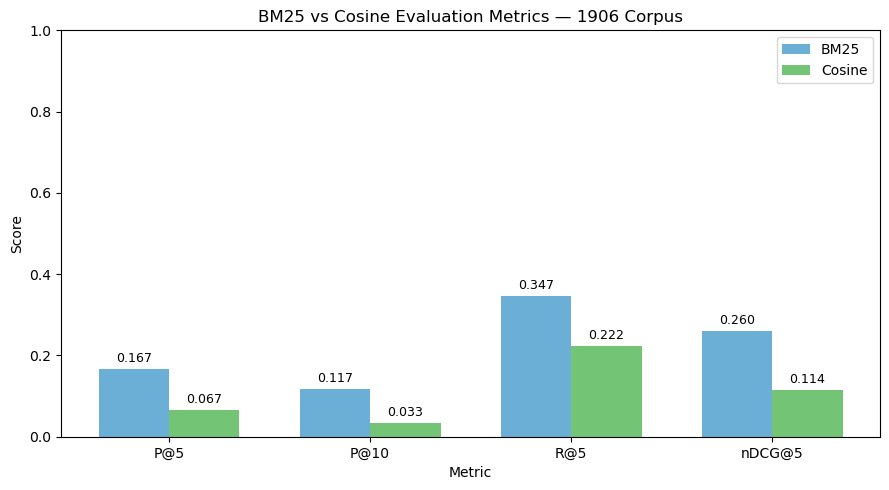

In [59]:
metrics = ["P_5", "P_10", "recall_5", "ndcg_cut_5"]
labels  = ["P@5", "P@10", "R@5", "nDCG@5"]

bm25_scores   = [eval_results.iloc[0][m] for m in metrics]
cosine_scores = [eval_results.iloc[1][m] for m in metrics]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, bm25_scores,   width, label="BM25",   color="#6baed6")
b2 = ax.bar(x + width/2, cosine_scores, width, label="Cosine", color="#74c476")

ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("BM25 vs Cosine Evaluation Metrics — 1906 Corpus")
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../data/eval_comparison.png", dpi=150)
plt.show()

## 11. Discussion

BM25 achieved P@5 = 0.167, P@10 = 0.117, R@5 = 0.347, and nDCG@5 = 0.260. Cosine similarity underperformed across all metrics (P@5 = 0.067, nDCG@5 = 0.114). Four queries (election, war, weather, disease) returned NaN because no relevant documents appeared in those results at all. Q7 (business) was the strongest result for BM25 with P@5 = 0.60 and nDCG@5 = 0.83. P@5 > P@10 shows relevant docs tend to rank near the top, meaning BM25 is working.

The low scores come down to two things. First, documents are full newspaper pages, not individual articles. Every page mixes ads, mastheads, and unrelated content, so query terms match incidentally rather than topically. Second, both newspapers are Black community press (Cleveland Gazette, St. Louis Palladium), which focus on community news and civil rights rather than weather, military, or electoral coverage.

BM25 outperforms cosine similarity likely because BM25's term frequency saturation and document length normalization are better suited to long, noisy OCR documents. Cosine similarity treats all TF-IDF dimensions equally, making it more sensitive to noise.

Segmenting pages into individual articles before indexing would likely improve results the most. Expanding beyond 608 pages would help coverage for the topics that returned nothing.